In [1]:
import tskit
import msprime
import pyslim 
import demesdraw as dem
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

/home/bjarkemp/miniforge3/envs/recapitation/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Functions

In [2]:
def count_coalescents_to_common_ancestor(ts, idx_left, idx_right, node):
    tree_left = ts.at_index(idx_left)
    tree_right =ts.at_index(idx_right)

    # ancestery path for node in left tree
    anc_path_left = []
    curr = node
    while curr != tskit.NULL:
        anc_path_left.append(curr)
        curr = tree_left.parent(curr)

    # ancestery path for node in right tree
    anc_path_right = []
    curr = node
    while curr != tskit.NULL:
        anc_path_right.append(curr)
        curr = tree_right.parent(curr)

    print(anc_path_left)
    print(anc_path_right)
    mrca = [x for x in anc_path_left if x in anc_path_right and x!=node][0]
    coal_c_left = anc_path_left.index(mrca)-1
    coal_c_right = anc_path_right.index(mrca)-1
    print(mrca)
    print('coalescents left:', coal_c_left)
    print('coalescents right:', coal_c_right)

    return (coal_c_left,coal_c_right)

# function to add mutations to all branches that are true coalescent nodes (2+ children)

def add_mutations(ts):
    tables = ts.tables
    tables.mutations.clear()
    tables.sites.clear()
    s = 0
    for t in ts.trees():
        left, right = t.interval
        # Count true coalescent nodes in this tree for position spacing
        coal_nodes = [n for n in t.nodes() if t.num_children(n) >= 2]
        n_coal = len(coal_nodes)
        for k, node in enumerate(coal_nodes):
            pos = left + (k + 1) * (right - left) / (n_coal + 1)
            tables.sites.add_row(position=pos, ancestral_state="A")
            tables.mutations.add_row(site=s, node=node, derived_state="G", time=None)
            s += 1

    tables.sort()
    return tables.tree_sequence()

def find_recsites(ts):
    recsites = set()
    for s in ts.sites():
        if len(s.mutations) > 1:
            recsites.add(s.id)
    return recsites


def compute_incompatibility_matrix(ts, recsites=set()):
    num_sites = ts.num_sites
    genotypes = ts.genotype_matrix()  # Shape: (num_sites, num_samples)
    matrix = np.zeros((num_sites, num_sites), dtype=np.int8)
    for i in tqdm(range(num_sites), desc="Computing incompatibility"):
        if i not in recsites:
            for j in range(i + 1, num_sites):
                if j not in recsites:
                    g1 = genotypes[i, :]
                    g2 = genotypes[j, :]

                    # Encode gametes as 2-bit integers: g1 + 2*g2
                    # 00 -> 0, 10 -> 1, 01 -> 2, 11 -> 3
                    gametes = g1 | (g2 << 1)

                    # Include ancestral root type (00)
                    gametes = np.append(gametes, 0)

                    # If all 4 gamete types exist, sites are incompatible
                    if len(np.unique(gametes)) == 4:
                        matrix[i, j] = 1
                        matrix[j, i] = 1  # Symmetric
    return matrix


def compute_gamete_proportions(ts, incomp_matrix):
    pairs_i, pairs_j = np.where(np.triu(incomp_matrix) == 1)
    num_pairs = len(pairs_i)

    coal_nodes = np.where(ts.tables.nodes.flags == 0)[0]
    nodes = np.concatenate([ts.samples(), coal_nodes])

    genotypes = ts.genotype_matrix(samples=nodes, isolated_as_missing=False)

    gamete_matrix = genotypes[pairs_i, :] | (genotypes[pairs_j, :] << 1)
    gamete_counts = np.array([(gamete_matrix == g).sum(axis=0) for g in range(4)]).T

    node_types = (["sample"] * len(ts.samples()) +
                ["coalescent"] * len(coal_nodes))

    df = pd.DataFrame(
        gamete_counts / num_pairs,
        index=[f"node_{i}" for i in nodes],
        columns=["00", "10", "01", "11"]
    )
    df["type"] = node_types
    df["time"] = ts.tables.nodes.time[nodes]

    return df

# Run tree

[803629.24511931]


/tmp/ipykernel_223859/3478814551.py:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  50, recombination_rate=1e-7, sequence_length=1e6, random_seed=int(seed), record_full_arg=True, model='smc')


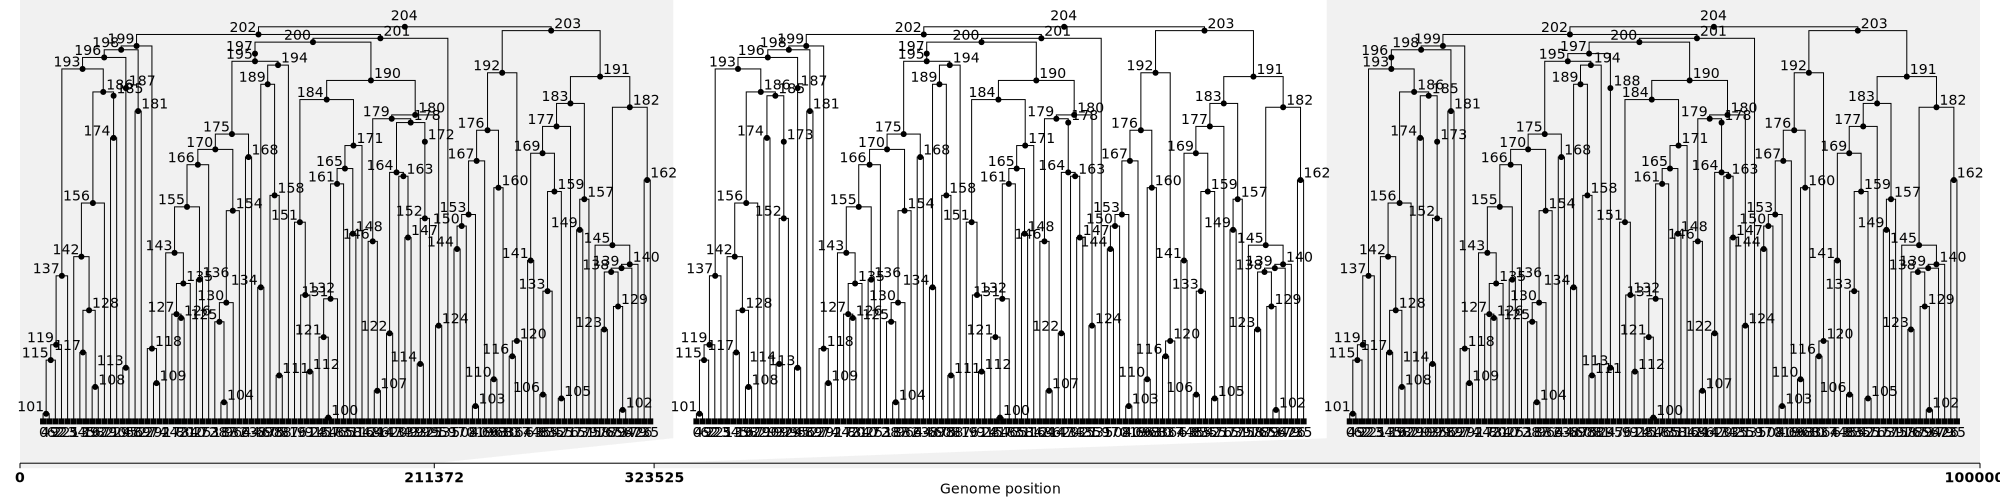

In [165]:
for i in range(1,1000):
    seed =  np.random.uniform(1,1000000,1)
    print(seed)
    ts = msprime.sim_ancestry(
        50, recombination_rate=1e-7, sequence_length=1e6, random_seed=int(seed), record_full_arg=True, model='smc')
    if ts.num_trees == 3:
        break
ts.draw_svg(size=(2000,500), time_scale='rank')

In [166]:
# Find recombination events                     
for node_id in range(ts.num_nodes - 1):         
    node1 = ts.node(node_id)                    
    if node1.flags == msprime.NODE_IS_RE_EVENT: 
        node2 = ts.node(node_id + 1)            
        if node2.flags == msprime.NODE_IS_RE_EVENT and node1.time == node2.time:                                     
            # Found a recombination event pair  
            print(f"Recombination event at nodes {node_id} and {node_id + 1}, time: {node1.time:.4f}")                              
                                                
            # Find the child (the lineage that recombined)                                     
            edges1 = [e for e in ts.edges() if e.parent == node_id]                            
            edges2 = [e for e in ts.edges() if e.parent == node_id + 1]                        
                                                
            if edges1 and edges2:               
                child = edges1[0].child         
                breakpoint = min(e.right for e in edges1)                                                                     
                print(f"  Recombinant lineage: node {child}")                                  
                print(f"  Breakpoint position: {breakpoint:.0f}")                              
                                                
                # Get descendant samples        
                tree = ts.at(breakpoint - 1)    
                descendants = list(tree.samples(child))                       
                print(f"  Descendant samples: {descendants}") 

Recombination event at nodes 172 and 173, time: 0.1014
  Recombinant lineage: node 152
  Breakpoint position: 211372
  Descendant samples: [99, 93, 97]
Recombination event at nodes 187 and 188, time: 0.2288
  Recombinant lineage: node 113
  Breakpoint position: 323525
  Descendant samples: [24, 95]


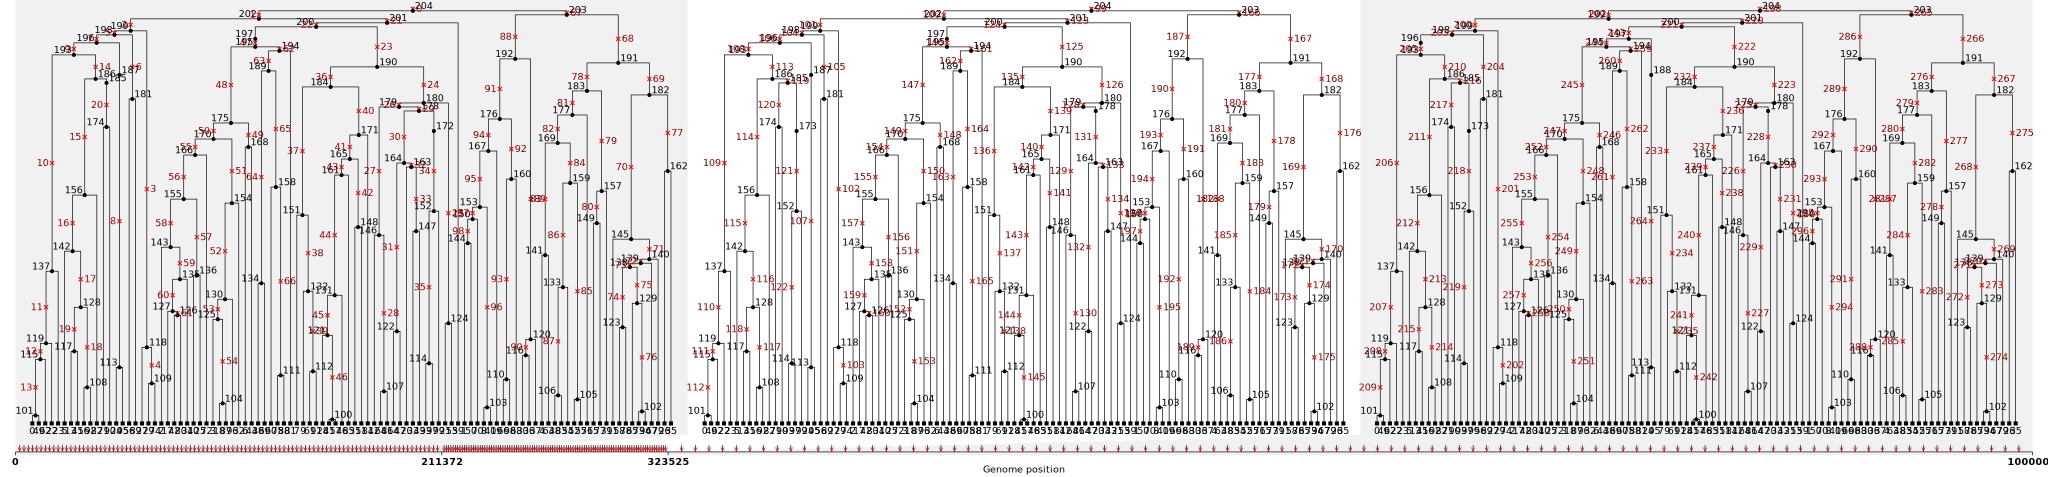

In [208]:
mts = add_mutations(ts)
mts.draw_svg(size=(3000,700), time_scale='rank')

In [209]:
mts = mts.simplify([s for s in mts.samples() if s not in [99, 93, 97]], keep_unary=True)

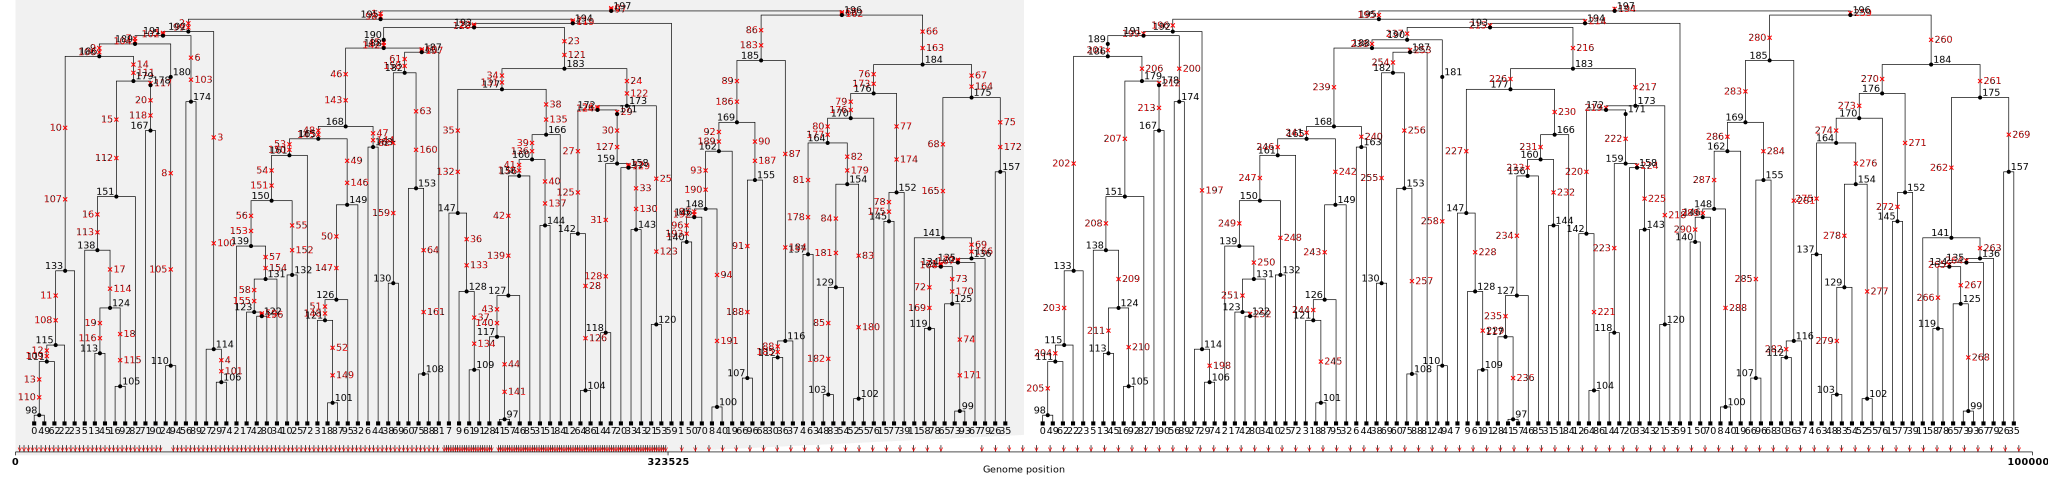

In [210]:
mts.draw_svg(size=(3000,700), time_scale='rank')

In [211]:
mts

In [192]:
# Run it                                                                          
incomp_matrix = compute_incompatibility_matrix(mts, recsites=find_recsites(mts))  

Computing incompatibility: 100%|██████████| 291/291 [00:00<00:00, 679.17it/s]


In [193]:
incomp_matrix

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(291, 291), dtype=int8)

In [194]:
np.where(incomp_matrix.any(axis=1))[0] 

array([  2,   5,   7,  21,  22,  99, 102, 104, 119, 120, 196, 199, 214,
       215, 237])

In [195]:
coal_nodes = np.where(mts.tables.nodes.flags == 0)[0]                                                                                                 
nodes = np.concatenate([mts.samples(), coal_nodes])                                                                                                   
genotypes = mts.genotype_matrix(samples=nodes, isolated_as_missing=False) 

In [196]:
genotypes

array([[1, 1, 1, ..., 1, 1, 1],
       [1, 0, 1, ..., 1, 0, 0],
       [1, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 1, 0, ..., 0, 0, 0],
       [0, 1, 0, ..., 0, 0, 0]], shape=(291, 194), dtype=int32)

In [197]:
incompatible_sites = np.where(incomp_matrix.any(axis=1))[0]  
#genotypes = mts.genotype_matrix()                            
incomp_genotypes = genotypes[incompatible_sites, :].T  
incomp_genotypes

array([[1, 1, 1, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 1, 1, 1],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(194, 15), dtype=int32)

In [198]:
# incom_site = 0
# site_idx = incompatible_sites[incom_site]
# partners = np.where(incomp_matrix[site_idx, :] == 1)[0]
# print(f"Site {site_idx} is incompatible with sites: {partners}")

# # For the first partner, show each individual's genotype at this pair
# partner = partners[0]
# g1 = genotypes[site_idx, :]
# g2 = genotypes[partner, :]
# # gametes = g1 | (g2 << 1)  # 0=00, 1=10, 2=01, 3=11

# print(f"\nSite {site_idx} vs Site {partner}:")
# print(f"Unique gametes: {np.unique(gametes)}")
# print()

# # Per-individual genotype pair at this incompatible pair
# n_samples = genotypes.shape[1]
# for ind in range(n_samples):
#     print(f"Individual {ind}: site {site_idx}={g1[ind]}, site {partner}={g2[ind]} -> gamete {gametes[ind]} ({g1[ind]}{g2[ind]})")


In [199]:
# # All incompatible pairs and per-individual gametes
# pairs = np.column_stack(np.where(np.triu(incomp_matrix) == 1))  # (n_pairs, 2)
# print(pairs)
# pair_gametes = genotypes[pairs[:, 0], :] | (genotypes[pairs[:, 1], :] << 1)  # (n_pairs, n_individuals)
# print(pair_gametes)

# print(f"Number of incompatible pairs: {len(pairs)}")
# print(f"pair_gametes shape: {pair_gametes.shape}")
# print(f"\nFirst pair: sites {pairs[0]} -> gametes: {pair_gametes[0, :]}")


In [200]:
compatible_sites = np.where(~incomp_matrix.any(axis=1))[0]                        
# mts_incomp = mts.delete_sites(compatible_sites)                                   
                                                                                
# mts_incomp.draw_svg(size=(2000, 700), time_scale='rank') 

In [201]:
# function for compairing sites on either side of a point

def incomp_pair_genotypes(incomp_genotypes, pair_matrix):
    """
    For each incompatible pair in pair_matrix, compute the genotype (0-3)
    for each individual.

    Parameters
    ----------
    incomp_genotypes : array of shape (n_individuals, n_sites), values 0 or 1
    pair_matrix : array of shape (n_sites, n_sites), 1 = incompatible pair

    Returns
    -------
    genotypes : array of shape (n_pairs, n_individuals)
    pairs : list of (i, j) tuples, one per row
    """
    n_sites = incomp_genotypes.shape[1]
    results = []
    pairs = []
    for i in range(n_sites):
        for j in range(i + 1, n_sites):
            if pair_matrix[i, j]:
                row = incomp_genotypes[:, i] | (incomp_genotypes[:, j] << 1)
                results.append(row)
                pairs.append((i, j))
    if len(results) == 0:
        return np.empty((0, incomp_genotypes.shape[0]), dtype=int), []
    return np.array(results), pairs


def cross_point_genotypes(all_genotypes, pairs, point):
    """
    Filter the full pair genotype matrix to only pairs that cross the point.

    Parameters
    ----------
    all_genotypes : array of shape (n_pairs, n_individuals), values 0-3
        Output of incomp_pair_genotypes.
    pairs : list of (i, j) tuples matching rows of all_genotypes
    point : int, the split point

    Returns
    -------
    genotypes : array of shape (n_crossing_pairs, n_individuals)
    """
    mask = [i < point and j >= point for i, j in pairs]
    if not any(mask):
        return np.empty((0, all_genotypes.shape[1]), dtype=int)
    return all_genotypes[mask]


def score_individuals(cross_genotypes, w=1):
    """
    Score each individual based on cross-point genotypes.

    For each site pair:
      - genotype == 3 (11): +1 to that individual's score
      - individual is the only one with its genotype in that pair: +w

    Parameters
    ----------
    cross_genotypes : array of shape (n_pairs, n_individuals), values 0-3
    w : float, weight for being the unique holder of a genotype

    Returns
    -------
    scores : array of shape (n_individuals,)
    """
    n_pairs, n_ind = cross_genotypes.shape
    scores = np.zeros(n_ind)

    # +1 for every genotype == 3
    scores += (cross_genotypes == 3).sum(axis=0)

    # +w for being the only individual with a given genotype in a pair
    for row_idx in range(cross_genotypes.shape[0]):

        row_data = cross_genotypes[row_idx,:]

        values, counts = np.unique(row_data,return_counts=True)
        unique_values_in_row = values[counts == 1]

        cols = np.where(np.isin(row_data,unique_values_in_row))[0]

        for col_idx in cols:
            scores[col_idx] += w

    return scores

In [202]:
sub_incomp = incomp_matrix[np.ix_(incompatible_sites, incompatible_sites)]
all_genos, pairs = incomp_pair_genotypes(incomp_genotypes, sub_incomp)
all_genos.shape
pairs

[(0, 12),
 (0, 13),
 (0, 14),
 (1, 10),
 (1, 12),
 (1, 13),
 (1, 14),
 (2, 10),
 (2, 11),
 (2, 12),
 (2, 13),
 (2, 14),
 (3, 13),
 (3, 14),
 (4, 14),
 (5, 12),
 (5, 13),
 (5, 14),
 (6, 10),
 (6, 12),
 (6, 13),
 (6, 14),
 (7, 10),
 (7, 11),
 (7, 12),
 (7, 13),
 (7, 14),
 (8, 13),
 (8, 14),
 (9, 14)]

In [203]:
# Sub-matrix of incomp_matrix for only the incompatible sites
sub_incomp = incomp_matrix[np.ix_(incompatible_sites, incompatible_sites)]

# Compute all incompatible pair genotypes once
all_genos, pairs = incomp_pair_genotypes(incomp_genotypes, sub_incomp)

# Filter to pairs crossing the point
cg = cross_point_genotypes(all_genos, pairs, point=5)

cg.shape


(15, 194)

In [204]:
pairs

[(0, 12),
 (0, 13),
 (0, 14),
 (1, 10),
 (1, 12),
 (1, 13),
 (1, 14),
 (2, 10),
 (2, 11),
 (2, 12),
 (2, 13),
 (2, 14),
 (3, 13),
 (3, 14),
 (4, 14),
 (5, 12),
 (5, 13),
 (5, 14),
 (6, 10),
 (6, 12),
 (6, 13),
 (6, 14),
 (7, 10),
 (7, 11),
 (7, 12),
 (7, 13),
 (7, 14),
 (8, 13),
 (8, 14),
 (9, 14)]

In [205]:
scores = score_individuals(cg, w=0.9)
scores

array([3., 0., 3., 3., 0., 3., 3., 1., 0., 1., 3., 0., 1., 3., 1., 0., 3.,
       3., 3., 0., 1., 1., 3., 3., 9., 3., 0., 0., 1., 0., 0., 1., 3., 1.,
       3., 0., 0., 0., 3., 0., 0., 1., 3., 1., 3., 3., 1., 1., 0., 3., 0.,
       1., 0., 1., 0., 0., 1., 1., 0., 0., 3., 1., 3., 0., 1., 0., 0., 0.,
       0., 3., 0., 3., 3., 0., 0., 3., 0., 0., 0., 0., 3., 3., 3., 0., 1.,
       1., 1., 3., 3., 1., 3., 1., 3., 0., 9., 3., 0., 1., 3., 0., 0., 3.,
       0., 0., 1., 3., 0., 0., 3., 1., 9., 3., 0., 3., 0., 3., 0., 1., 1.,
       0., 1., 3., 3., 3., 3., 0., 3., 1., 1., 0., 3., 3., 3., 3., 0., 0.,
       0., 0., 3., 3., 0., 0., 1., 1., 1., 0., 0., 1., 0., 3., 3., 3., 0.,
       3., 0., 0., 1., 0., 1., 1., 1., 3., 0., 3., 0., 3., 1., 3., 3., 0.,
       0., 1., 1., 1., 0., 0., 1., 3., 3., 1., 0., 0., 3., 3., 3., 0., 0.,
       1., 0., 1., 0., 0., 0., 0.])

0.0
0.1
0.2
0.3
0.4
0.5
0.6
0.7
0.8
0.9
1.0


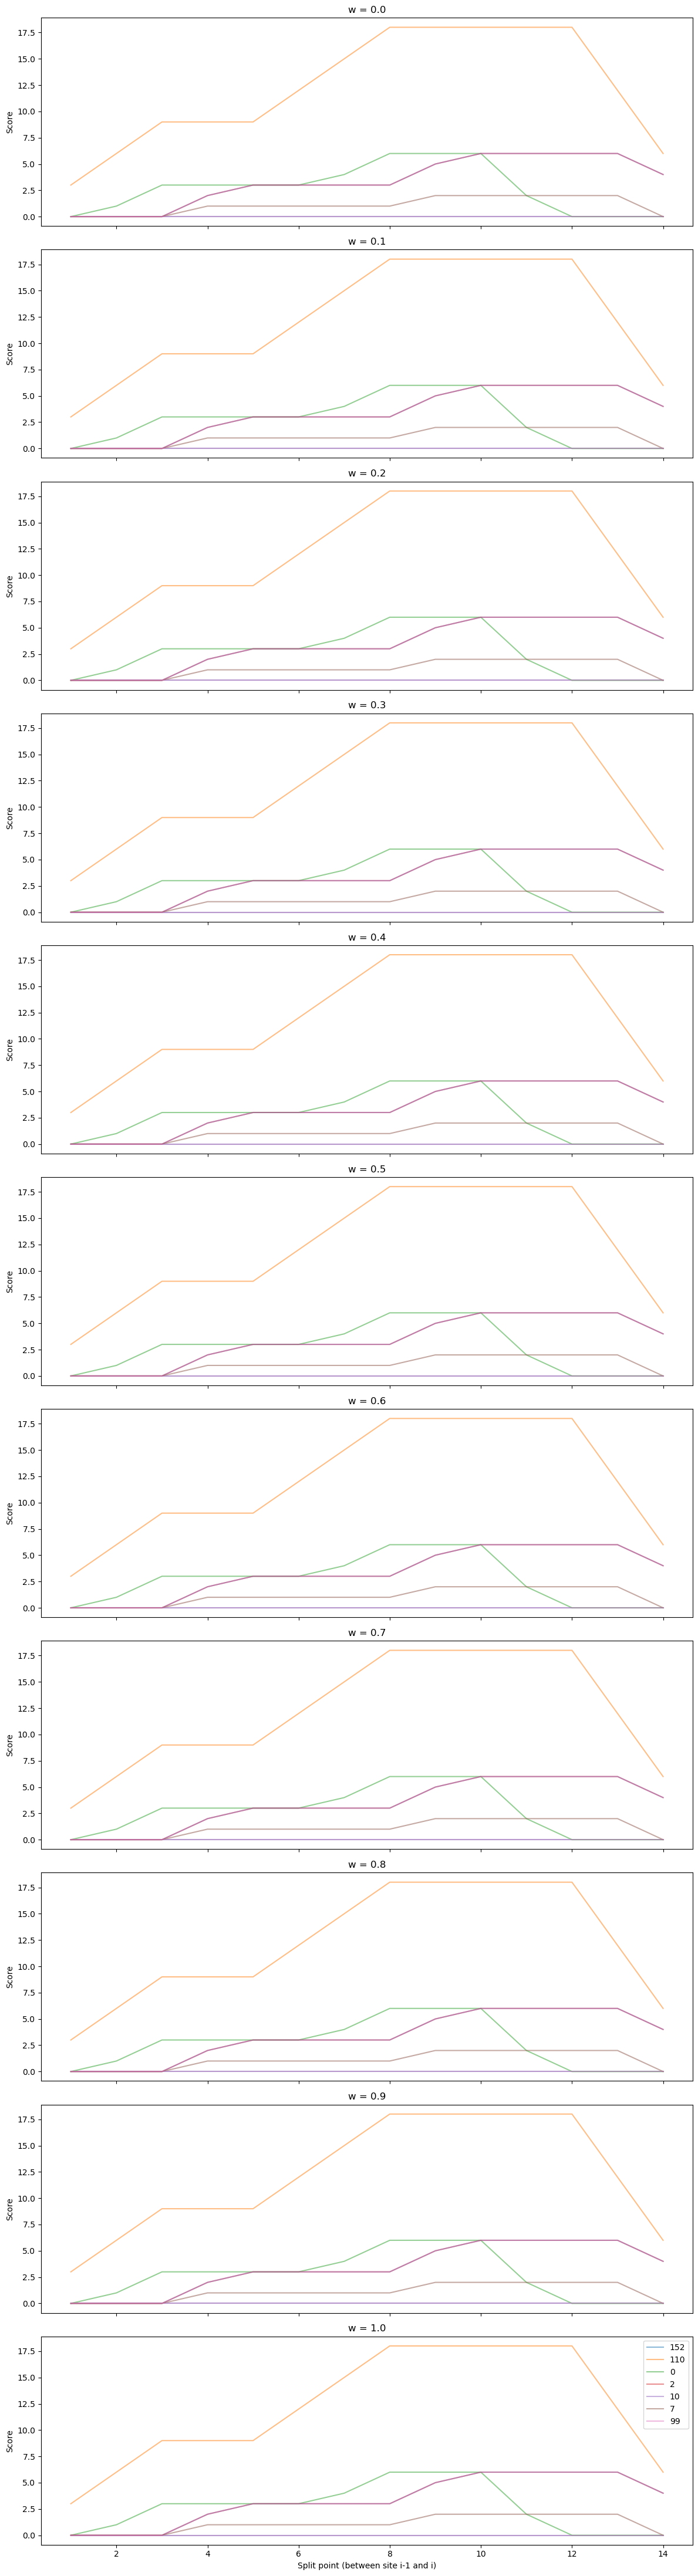

In [212]:
# Score at each split point across incompatible sites, for each w
n_sites = incomp_genotypes.shape[1]
n_ind = incomp_genotypes.shape[0]
w_values = np.round(np.arange(0, 1.1, 0.1), 1)

# Precompute cross_point_genotypes for each split point (shared across w)
cross_genos = [cross_point_genotypes(all_genos, pairs, point) for point in range(1, n_sites)]

fig, axes = plt.subplots(len(w_values), 1, figsize=(12, 4 * len(w_values)), sharex=True)

for ax, w in zip(axes, w_values):
    print(w)
    score_matrix = np.zeros((n_sites - 1, n_ind))
    for i, cg in enumerate(cross_genos):
        if cg.shape[0] > 0:
            score_matrix[i] = score_individuals(cg, w=w)

    for ind in [152,110,0,2,10,7,99]:
        ax.plot(range(1, n_sites), score_matrix[:, ind], alpha=0.5, label=ind)

    ax.set_ylabel("Score")
    ax.set_title(f"w = {w:.1f}")

axes[-1].set_xlabel("Split point (between site i-1 and i)")
plt.legend()
plt.tight_layout()
plt.show()

# FOR LATER

In [ ]:
df = compute_gamete_proportions(mts, incomp_matrix)

In [ ]:
re_nodes = np.where(ts.tables.nodes.flags & msprime.NODE_IS_RE_EVENT > 0)[0]
edges = ts.tables.edges

# Build parent -> children map
from collections import defaultdict
children_map = defaultdict(set)
for i in range(len(edges)):
    children_map[edges.parent[i]].add(edges.child[i])

# Pair recombination nodes into events
rec_events = [(re_nodes[i], re_nodes[i+1]) for i in range(0, len(re_nodes), 2)]

# For each event, BFS downward and tag all descendants
node_rec_events = defaultdict(set)
for event_id, (rn_left, rn_right) in enumerate(rec_events):
    stack = [rn_left, rn_right]
    visited = set()
    while stack:
        node = stack.pop()
        for child in children_map.get(node, set()):
            if child not in visited:
                visited.add(child)
                node_rec_events[child].add(event_id)
                stack.append(child)

# Reconstruct the same node order as compute_gamete_proportions
coal_nodes = np.where(mts.tables.nodes.flags == 0)[0]
all_nodes = np.concatenate([mts.samples(), coal_nodes])

df["rec_events"] = [sorted(node_rec_events.get(n, [])) for n in all_nodes]
df

# Population structure

In [ ]:
import msprime
import tskit
import numpy as np

# Parameters
N = 200
split_time = 500

# ==========================================
# Phase 1: Pop A with recombination
# ==========================================
ts_A = msprime.sim_ancestry(
    samples=N,
    population_size=N,
    recombination_rate=1e-9,
    sequence_length=1e8,
    end_time=split_time,
    model="smc",
    record_full_arg=True, 
)

# ==========================================
# Phase 2: Pop B without recombination
# ==========================================
ts_B = msprime.sim_ancestry(
    samples=N,
    population_size=N,
    recombination_rate=0,
    sequence_length=1e8,
    end_time=split_time,
    record_full_arg=True
)

# ==========================================
# Merge — Combine tables and assign Populations
# ==========================================
# 1. Union the TreeSequences
# node_mapping is required by .union() to map the nodes of the second TS
node_mapping = np.full(ts_B.num_nodes, tskit.NULL, dtype=np.int32)
ts_combined = ts_A.union(ts_B, node_mapping=node_mapping)

# 2. Update Population Metadata and Node Assignments
tables = ts_combined.dump_tables()

# Clear default populations and define our custom schema
tables.populations.clear()
tables.populations.metadata_schema = tskit.MetadataSchema.permissive_json()
tables.populations.add_row(metadata={"name": "A", "description": "recombining population"})       # ID 0
tables.populations.add_row(metadata={"name": "B", "description": "non-recombining population"})   # ID 1
tables.populations.add_row(metadata={"name": "ancestral", "description": "ancestral population"}) # ID 2

# Assign nodes to correct populations
# Nodes 0 to num_A_nodes-1 are from ts_A -> Pop 0 (A)
# Nodes num_A_nodes to end are from ts_B -> Pop 1 (B)
num_A_nodes = ts_A.num_nodes
pop_col = tables.nodes.population
pop_col[:num_A_nodes] = 0 
pop_col[num_A_nodes:] = 1 
tables.nodes.population = pop_col

# Finalize the combined initial state
ts_combined = tables.tree_sequence()

# ==========================================
# Phase 3: Coalesce in ancestral pop
# ==========================================
demography = msprime.Demography()

# Define populations (keep them active to avoid "inactive population" errors)
demography.add_population(name="A", initial_size=N)
demography.add_population(name="B", initial_size=N)
demography.add_population(name="ancestral", initial_size=N)

# FIX: Use Mass Migration 
# This ensures simulation initializes at t=500, loads the lineages, 

migration_time = split_time + 1e-6

demography.add_mass_migration(
    time=migration_time, 
    source="A", 
    dest="ancestral", 
    proportion=1.0
)
demography.add_mass_migration(
    time=migration_time, 
    source="B", 
    dest="ancestral", 
    proportion=1.0
)

# Run the simulation starting from the combined state
ts = msprime.sim_ancestry(
    initial_state=ts_combined,
    demography=demography,
    recombination_rate=0,
    start_time=split_time,
    record_full_arg=True 
)

# ==========================================
# Verification
# ==========================================
print(f"Final TreeSequence Summary:")
print(f"  Trees: {ts.num_trees}")
print(f"  Samples: {ts.num_samples}")

In [ ]:
ts

In [ ]:
len(ts.samples())

In [ ]:
# Downsample to 10 individuals (20 haploid nodes)
sample_nodes = ts.samples()
rng = np.random.default_rng()
subsample = rng.choice(sample_nodes, size=20, replace=False)
ts_sub = ts.simplify(samples=subsample, keep_unary=True)
print(f"Trees: {ts_sub.num_trees}, Samples: {ts_sub.num_samples}")
ts_sub

In [ ]:
ts_sub.at_index(0).draw_svg(size=(1000,500))

In [ ]:
ts_sub.at_index(1).draw_svg(size=(1000,500))

In [ ]:
mts = add_mutations(ts_sub)

In [ ]:
mts.at_index(2).draw_svg(size=(1000,500))

In [ ]:
mts

In [ ]:
# Run it                                                                          
incomp_matrix = compute_incompatibility_matrix(mts, recsites=find_recsites(mts))  

In [ ]:
compatible_sites = np.where(~incomp_matrix.any(axis=1))[0]                        
mts_incomp = mts.delete_sites(compatible_sites)                                   
                                                                                
mts_incomp.at_index(2).draw_svg(size=(1000, 600), time_scale='rank') 

In [ ]:
df = compute_gamete_proportions(mts, incomp_matrix)

In [ ]:
re_nodes = np.where(mts.tables.nodes.flags & msprime.NODE_IS_RE_EVENT > 0)[0]
edges = mts.tables.edges

# Build parent -> children map
from collections import defaultdict
children_map = defaultdict(set)
for i in range(len(edges)):
    children_map[edges.parent[i]].add(edges.child[i])

# Pair recombination nodes into events
rec_events = [(re_nodes[i], re_nodes[i+1]) for i in range(0, len(re_nodes)-1, 2)]

# For each event, BFS downward and tag all descendants
node_rec_events = defaultdict(set)
for event_id, (rn_left, rn_right) in enumerate(rec_events):
    stack = [rn_left, rn_right]
    visited = set()
    while stack:
        node = stack.pop()
        for child in children_map.get(node, set()):
            if child not in visited:
                visited.add(child)
                node_rec_events[child].add(event_id)
                stack.append(child)

# Reconstruct the same node order as compute_gamete_proportions
coal_nodes = np.where(mts.tables.nodes.flags == 0)[0]
all_nodes = np.concatenate([mts.samples(), coal_nodes])

df["population"] = [mts.population(mts.node(n).population).metadata['name'] for n in all_nodes]
df["rec_events"] = [sorted(node_rec_events.get(n, [])) for n in all_nodes]
df

In [ ]:
pd.set_option('display.max_rows', None)    
df

In [ ]:
pd.reset_option('display.max_rows')